In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [2]:
confirmed = pd.read_csv('../data/confirmed.csv')
deaths = pd.read_csv('../data/deaths.csv')
recovered = pd.read_csv('../data/recovered.csv')

In [3]:
import os
print(os.listdir('../data'))

['.ipynb_checkpoints', 'confirmed.csv', 'deaths.csv', 'recovered.csv']


In [4]:
cols = ['Province/State', 'Lat', 'Long']

confirmed = confirmed.drop(cols, axis=1).groupby('Country/Region').sum()
deaths = deaths.drop(cols, axis=1).groupby('Country/Region').sum()
recovered = recovered.drop(cols, axis=1).groupby('Country/Region').sum()

# Transpose
confirmed = confirmed.T
deaths = deaths.T
recovered = recovered.T

# Convert index to datetime
confirmed.index = pd.to_datetime(confirmed.index, format='%m/%d/%y')
deaths.index = pd.to_datetime(deaths.index, format='%m/%d/%y')
recovered.index = pd.to_datetime(recovered.index, format='%m/%d/%y')

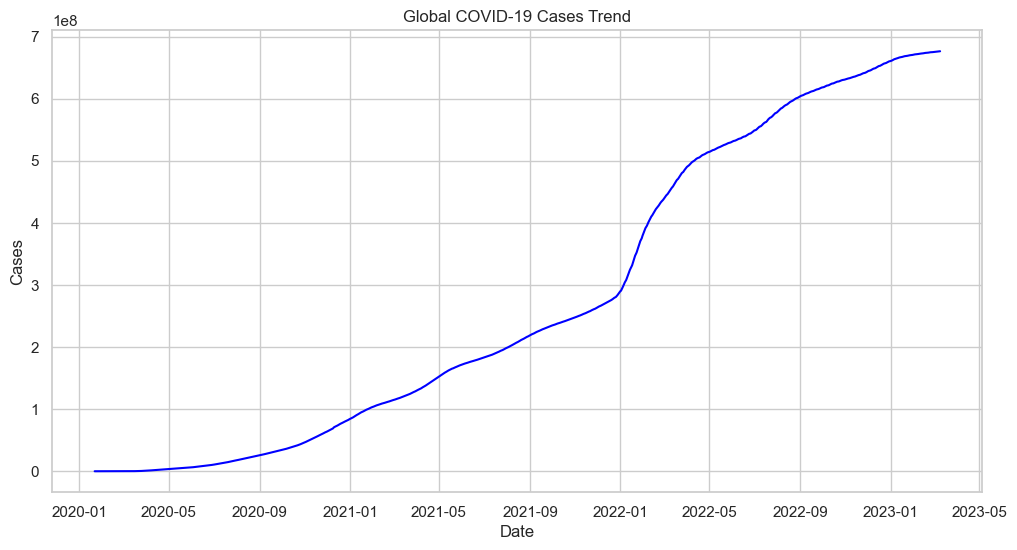

In [5]:
confirmed['Global'] = confirmed.sum(axis=1)

plt.plot(confirmed['Global'], color='blue')
plt.title("Global COVID-19 Cases Trend")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

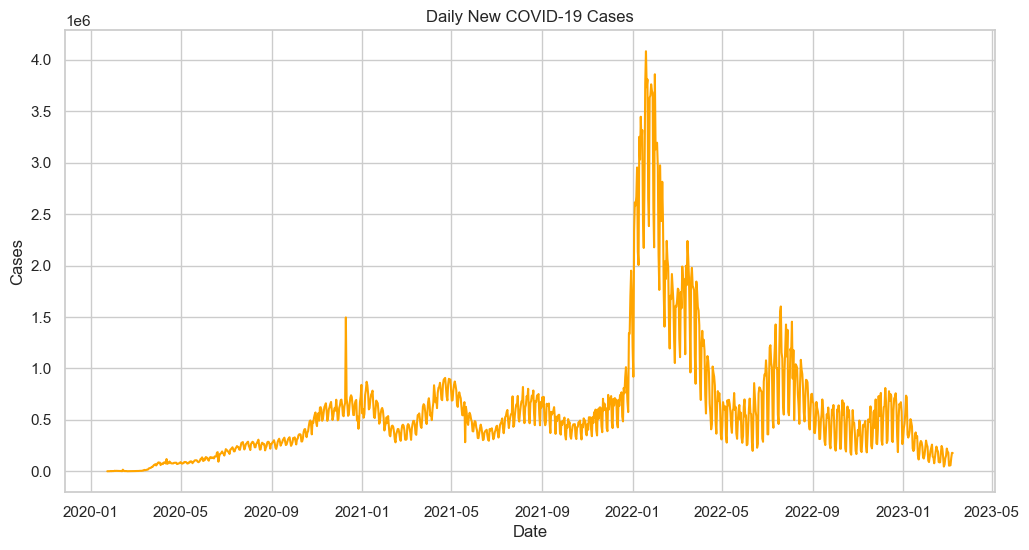

In [6]:
daily = confirmed['Global'].diff()

plt.plot(daily, color='orange')
plt.title("Daily New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

In [7]:
# Create top10 data
top10 = confirmed.iloc[-1].sort_values(ascending=False).head(10)

top10

Country/Region
Global            676570149
US                103802702
India              44690738
France             39866718
Germany            38249060
Brazil             37076053
Japan              33320438
Korea, South       30615522
Italy              25603510
United Kingdom     24658705
Name: 2023-03-09 00:00:00, dtype: int64

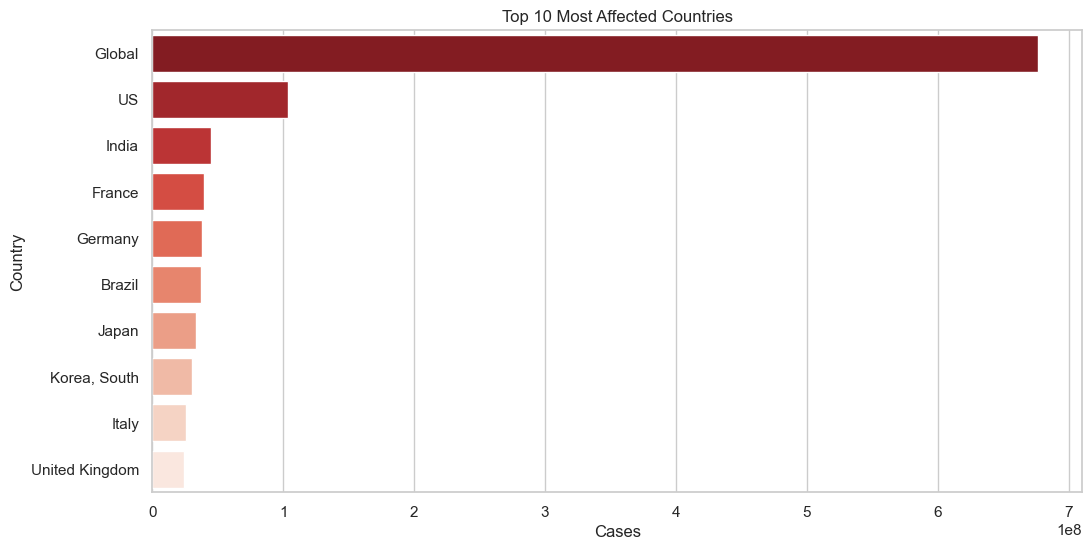

In [8]:
sns.barplot(
    x=top10.values, 
    y=top10.index, 
    hue=top10.index,     # 👈 add this
    palette="Reds_r",
    legend=False         # 👈 prevent extra legend
)

plt.title("Top 10 Most Affected Countries")
plt.xlabel("Cases")
plt.ylabel("Country")
plt.show()

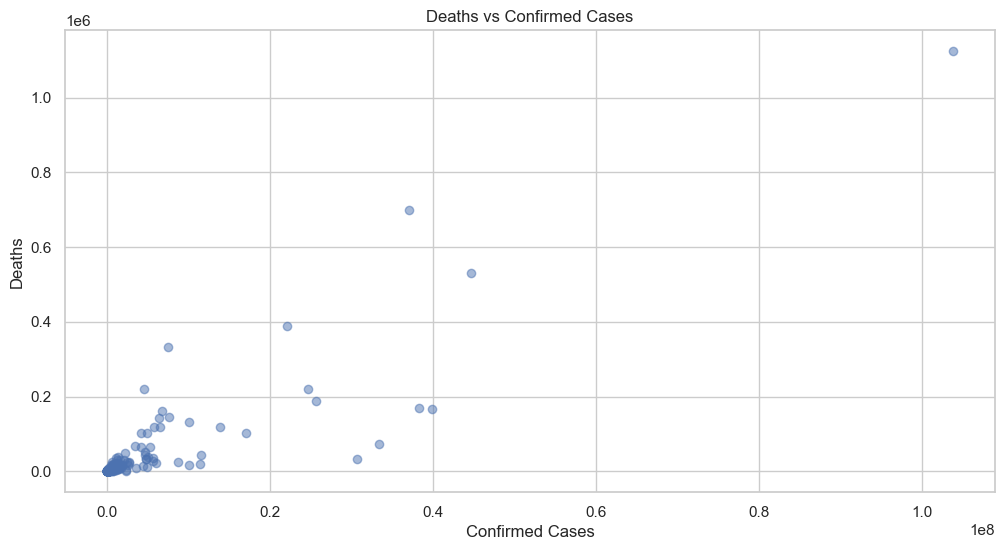

In [9]:
# Align both datasets (IMPORTANT)
common_countries = confirmed.columns.intersection(deaths.columns)

latest_confirmed = confirmed.iloc[-1][common_countries]
latest_deaths = deaths.iloc[-1][common_countries]

# Remove NaN values
df = pd.DataFrame({
    'Confirmed': latest_confirmed,
    'Deaths': latest_deaths
}).dropna()

# Scatter plot
plt.scatter(df['Confirmed'], df['Deaths'], alpha=0.5)
plt.title("Deaths vs Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.show()

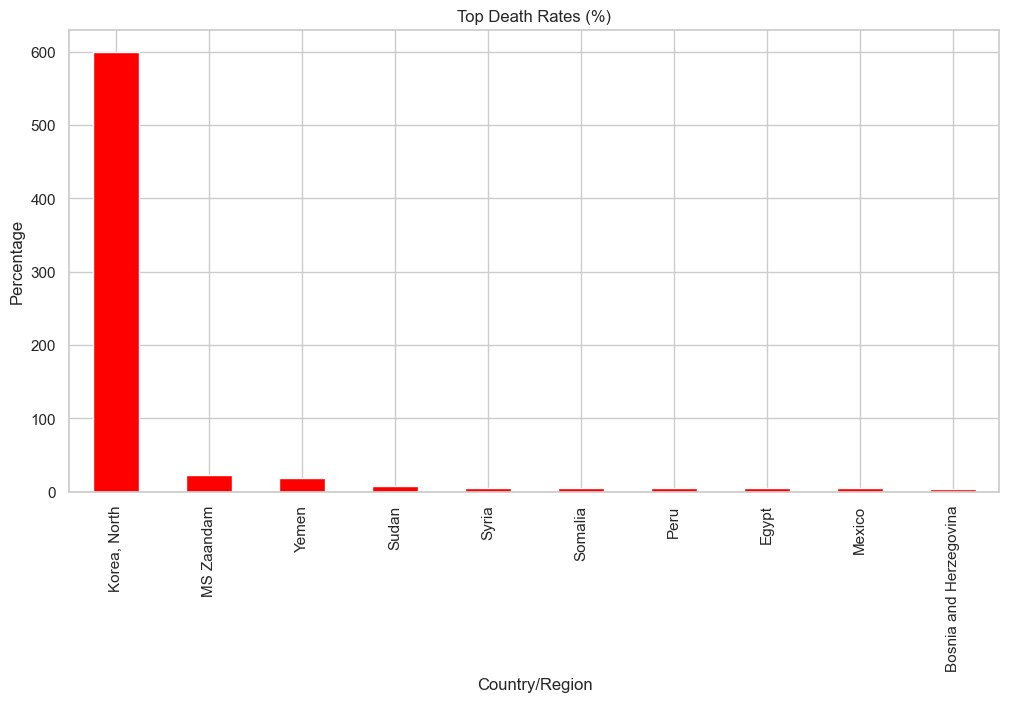

In [10]:
death_rate = (deaths.iloc[-1] / confirmed.iloc[-1]) * 100
top_death = death_rate.sort_values(ascending=False).head(10)

top_death.plot(kind='bar', color='red')
plt.title("Top Death Rates (%)")
plt.ylabel("Percentage")
plt.show()

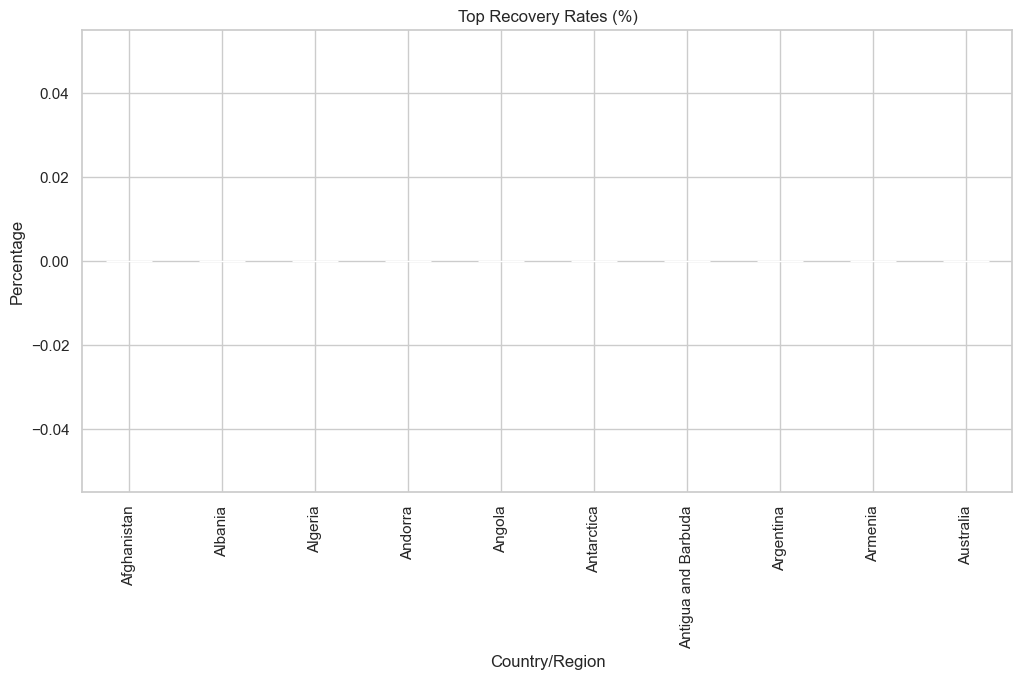

In [11]:
recovery_rate = (recovered.iloc[-1] / confirmed.iloc[-1]) * 100
top_recovery = recovery_rate.sort_values(ascending=False).head(10)

top_recovery.plot(kind='bar', color='green')
plt.title("Top Recovery Rates (%)")
plt.ylabel("Percentage")
plt.show()

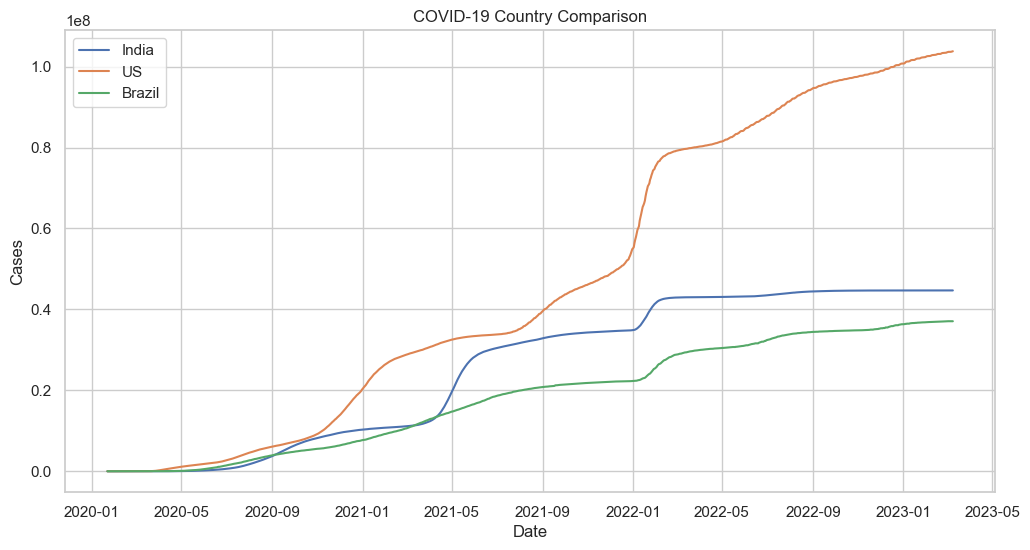

In [12]:
countries = ['India', 'US', 'Brazil']

for c in countries:
    plt.plot(confirmed[c], label=c)

plt.title("COVID-19 Country Comparison")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()

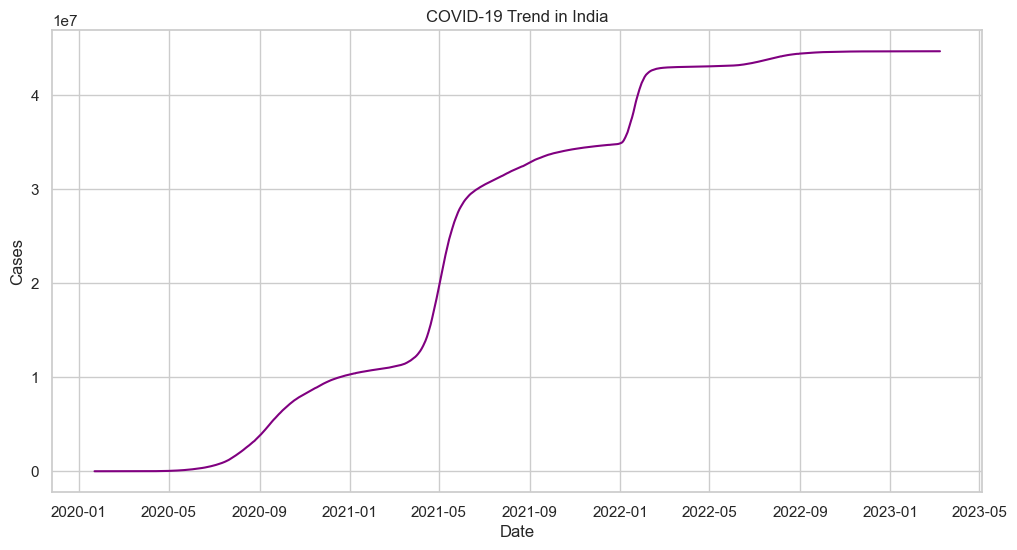

In [13]:
plt.plot(confirmed['India'], color='purple')
plt.title("COVID-19 Trend in India")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

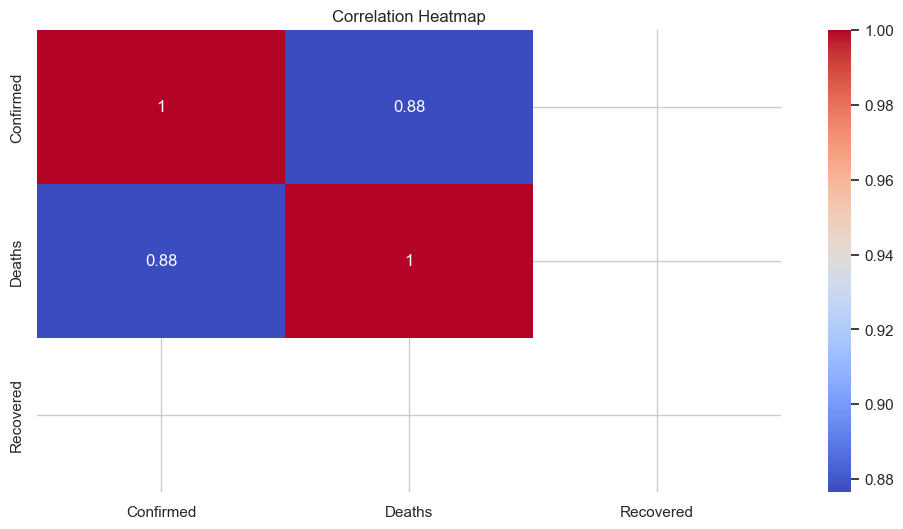

In [14]:
import numpy as np

merged = pd.DataFrame({
    'Confirmed': confirmed.iloc[-1],
    'Deaths': deaths.iloc[-1],
    'Recovered': recovered.iloc[-1]
})

sns.heatmap(merged.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()